# Selecting ARPU Drivers Across the Revenue Distribution with PROC QUANTSELECT

## Executive Summary

A telecom analytics team wants to know which customer attributes drive monthly revenue (ARPU) and how those drivers differ for low-spend versus high-spend subscribers. Ordinary least squares models only the conditional **mean**, and it also keeps every candidate predictor whether or not it earns its place. This notebook uses **PROC QUANTSELECT** to do both jobs that single mean model cannot: it performs automated **effect selection** (LASSO) *and* fits the selected model at the 10th, 50th, and 90th revenue percentiles in one call.

Two headline results come straight from the output below.

**Selection.** Run with `SELECTION=LASSO(CHOOSE=AIC STOP=AIC)`, the LASSO path enters the effects in order of importance — `contract` first, then `tenure_months`, `streaming_services`, `intl_minutes`, `data_gb`, `region`, and finally `support_calls` — driving AIC down from **228.77** (intercept only) to **124.37**, and the AIC criterion keeps all seven candidate effects in the final model.

**The revenue fan.** Across the three quantiles, the per-gigabyte ARPU slope rises from **0.288 USD/GB at the 10th percentile** to **0.872 at the median** and **1.057 at the 90th percentile** — an extra gigabyte is worth roughly **3.7x more** to a top-decile subscriber than to a bottom-decile one. That heteroscedastic revenue fan is exactly what a single mean model would average away.

## Data Sources

All data are generated inline by a DATA step (`call streaminit(90210)`); no external files are read. The simulation creates a 100-subscriber billing table by design, and the analysis is built to be meaningful at n = 100.

| Dataset | Rows | Key Variables | Description |
|---------|------|---------------|-------------|
| `work.subscribers` | 100 | `monthly_charge` (response), `tenure_months`, `data_gb`, `support_calls`, `intl_minutes`, `streaming_services`, `contract`, `region` | Synthetic monthly billing records for postpaid mobile subscribers. `monthly_charge` (ARPU, USD) is built from tenure, data usage, streaming add-ons, international usage, and contract type, with **heteroscedastic** noise that widens for high-data, month-to-month customers so the quantile structure is non-trivial. |

Variable detail:

| Variable | Type | Domain | Role |
|----------|------|--------|------|
| `contract` | char | Month-to-Month, One-Year, Two-Year | CLASS predictor |
| `region` | char | Metro, Suburban, Rural | CLASS predictor |
| `tenure_months` | num | 1-72 | Continuous predictor |
| `data_gb` | num | ~1-80 GB | Continuous predictor (primary ARPU driver) |
| `support_calls` | num | 0-12 | Continuous predictor |
| `intl_minutes` | num | 0-400 | Continuous predictor |
| `streaming_services` | num | 0-4 | Continuous predictor |
| `monthly_charge` | num | ~18-142 USD | Response (ARPU) |

# Modeling Telecom Customer ARPU with PROC QUANTSELECT

Average Revenue Per User (**ARPU**) is the headline KPI for any mobile carrier, but the drivers of revenue are rarely uniform across the customer base. The factors that separate a low-spend, churn-prone subscriber from a premium power user are often *different in degree* across the distribution, and a carrier rarely knows in advance *which* of its many candidate attributes actually matter. A single ordinary-least-squares model answers neither question: it targets only the conditional **mean**, and it retains every predictor you hand it.

**PROC QUANTSELECT** addresses both. It combines **quantile regression** — which estimates the conditional 10th, 50th, and 90th percentiles of `monthly_charge` directly — with automated **effect selection** (LASSO, forward, backward, or stepwise). The LASSO penalty path enters effects in order of contribution and reports an information criterion (AIC/SBC) at each step, so we can read off both *which* drivers earn a place and *how strongly* each one acts at the bottom, middle, and top of the revenue distribution.

In this notebook we will:

1. Generate a realistic synthetic subscriber billing table with **heteroscedastic** revenue noise.
2. Inspect the response distribution to confirm the right-skewed, fan-shaped structure.
3. Run PROC QUANTSELECT with LASSO selection at three revenue percentiles, reading the selection path and the per-quantile parameter estimates.
4. Overlay the three fitted lines to visualize the revenue fan.
5. Interpret the high-spend versus low-spend story and the selection result.

## Step 1 — Generate synthetic subscriber data

We simulate 100 postpaid subscribers. `monthly_charge` is a deterministic function of tenure, data usage, streaming add-ons, international usage, support burden, contract type, and region, plus **heteroscedastic** noise whose spread grows with data usage and is largest for month-to-month customers. That structure guarantees the conditional quantiles fan out, which is exactly the situation quantile regression is built for. The `streaminit` seed makes the table fully reproducible.

In [1]:
data subscribers;
    call streaminit(90210);
    length contract $13 region $9;
    do id = 1 to 100;
        /* Contract mix: month-to-month dominates the base */
        u = rand('uniform');
        if u < 0.50 then contract = 'Month-to-Month';
        else if u < 0.80 then contract = 'One-Year';
        else contract = 'Two-Year';

        /* Region mix */
        r = rand('uniform');
        if r < 0.40 then region = 'Metro';
        else if r < 0.75 then region = 'Suburban';
        else region = 'Rural';

        /* Tenure: longer-tenure customers skew to longer contracts */
        if contract = 'Two-Year' then tenure_months = round(rand('uniform') * 48 + 24);
        else if contract = 'One-Year' then tenure_months = round(rand('uniform') * 36 + 12);
        else tenure_months = round(rand('uniform') * 30 + 1);

        /* Usage drivers */
        data_gb            = round(rand('gamma', 2.2) * 7, 0.1);
        intl_minutes       = round(rand('exponential') * 45);
        streaming_services = rand('table', 0.45, 0.25, 0.18, 0.08, 0.04) - 1;
        support_calls      = rand('poisson', 1.6);

        /* Deterministic revenue core (USD) */
        base = 25
             + 0.95  * data_gb
             + 4.50  * streaming_services
             + 0.045 * intl_minutes
             + 0.12  * tenure_months
             - 0.80  * support_calls;
        if contract = 'One-Year' then base = base + 6;
        else if contract = 'Two-Year' then base = base + 11;
        if region = 'Metro' then base = base + 5;
        else if region = 'Rural' then base = base - 3;

        /* Heteroscedastic noise: widens with data usage,
           widest for month-to-month subscribers */
        sd = 4 + 0.35 * data_gb;
        if contract = 'Month-to-Month' then sd = sd * 1.6;
        monthly_charge = round(base + rand('normal', 0, sd), 0.01);
        if monthly_charge < 18 then monthly_charge = 18;

        output;
    end;
    keep id contract region tenure_months data_gb intl_minutes
         streaming_services support_calls monthly_charge;
run;

NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Step 2 — Inspect the synthetic distribution

A quick look at the response confirms the right-skewed, heteroscedastic shape that motivates quantile regression. The median `monthly_charge` is about 53 USD, but the gap between the 90th (74) and 10th (27) percentiles is wide, and `data_gb` ranges from 1 to 80 GB with a long right tail. Contract type is associated with both the level and the spread of ARPU: month-to-month subscribers have the lowest mean and by far the largest standard deviation.

In [2]:
proc means data=subscribers n mean std min p10 median p90 max maxdec=2;
    var monthly_charge data_gb tenure_months intl_minutes;
run;

proc means data=subscribers n mean std p10 median p90 maxdec=2;
    class contract;
    var monthly_charge;
run;

                                                  The MEANS Procedure

 Variable               N        Mean     Std Dev     Minimum   10th Pctl      Median   90th Pctl     Maximum
 ------------------------------------------------------------------------------------------------------------
 monthly_charge       100       52.70       20.70       18.00       26.61       53.42       73.95      141.72
 data_gb              100       16.43       12.84        1.00        4.53       13.35       33.89       80.00
 tenure_months        100       28.24       17.77        1.00        6.10       25.50       56.80       68.00
 intl_minutes         100       43.44       50.57        0.00        3.00       25.00      129.90      253.00
 ------------------------------------------------------------------------------------------------------------

                                                  The MEANS Procedure

                                           Analysis Variable : monthly_charge

        

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Step 3 — Selection plus quantile regression with PROC QUANTSELECT

We hand PROC QUANTSELECT all seven candidate effects and let it do the work. `SELECTION=LASSO(CHOOSE=AIC STOP=AIC)` traces the LASSO penalty path, adding effects one at a time, and uses AIC both to decide when to stop and which step's model to report. `contract` and `region` enter through the **CLASS** statement so each level's effect is read against a baseline. We list all three quantiles on `QUANTILE=`, so a single call returns the LASSO selection path plus parameter estimates at the 10th, 50th, and 90th percentiles.

Two ODS OUTPUT tables capture the result for printing: `SelectionSummary` (the entry order and information criteria at each step) and `ParameterEstimates` (the fitted coefficients, one block per quantile). Comparing the `data_gb` row across the three quantile blocks is the core question: if its slope grows from P10 to P90, an extra gigabyte is worth more at the top of the revenue distribution than at the bottom.

In [3]:
ods output SelectionSummary=selsum ParameterEstimates=parmest;

proc quantselect data=subscribers;
    class contract region;
    model monthly_charge = data_gb streaming_services tenure_months
                           intl_minutes support_calls contract region
        / quantile=0.10 0.50 0.90
          selection=lasso(choose=aic stop=aic);
run;

ods output close;


The QUANTSELECT Procedure

Dependent Variable: MONTHLY_CHARGE
Selection Method: LASSO
Quantile Level(s): 0.1000, 0.5000, 0.9000
Number of Observations Read: 100

Selection Summary

Step   Effect Entered/Removed      NumIn            AIC            SBC
----------------------------------------------------------------------
0      Intercept                       1       228.7746       231.3798
1      contract                        3       175.8190       183.6345
2      tenure_months                   4       177.2138       187.6345
3      streaming_services              5       163.8803       176.9061
4      intl_minutes                    6       155.1959       170.8269
5      data_gb                         7       148.1855       166.4217
6      region                          9       138.0023       161.4489
7      support_calls                  10       124.3694       150.4211

Selected Effects: contract tenure_months streaming_services intl_minutes data_gb region support_calls

Para

NOTE: ODS OUTPUT: SELECTIONSUMMARY -> selsum
NOTE: ODS OUTPUT: PARAMETERESTIMATES -> parmest
NOTE: PROC QUANTSELECT data=subscribers

NOTE: Using Python scipy version 1.17.1
NOTE: PROC QUANTSELECT completed.
NOTE: ODS OUTPUT: All output destinations closed.


## Step 3 results — read the selection path and the slopes

The `SelectionSummary` shows the order in which LASSO admitted effects and how the fit improved. `contract` enters first (AIC drops from 228.77 to 175.82), followed by `tenure_months`, `streaming_services`, `intl_minutes`, `data_gb`, `region`, and `support_calls`; AIC keeps falling to **124.37**, so the AIC stopping rule retains all seven candidate effects.

The `ParameterEstimates` table reports the selected model at each quantile in three stacked blocks (P10, P50, P90). The `data_gb` coefficient is the one to watch across those blocks.

In [4]:
proc print data=selsum noobs;
    title 'LASSO Selection Summary (AIC-chosen path)';
run;

proc print data=parmest noobs;
    title 'Quantile Parameter Estimates at P10, P50, P90';
run;

                                       LASSO Selection Summary (AIC-chosen path)                                        

STEP       EFFECTENTERED  EFFECTREMOVED  NUMBEREFFECTSIN             AIC             SBC           ACL
   0  Intercept                                        1  228.7746498524  231.3798200384       3.10767
   1  contract                                         3  175.8189632646  183.6344738226       2.33753
   2  tenure_months                                    4   177.213849762   187.634530506  2.3304683333
   3  streaming_services                               5  163.8802981078  176.9061490377      2.158474
   4  intl_minutes                                     6  155.1958520494  170.8268731653  2.0461894535
   5  data_gb                                          7   148.185485114  166.4216764159   1.956050571
   6  region                                           9  138.0023232182  161.4488548921  1.8221399664
   7  support_calls                                   

NOTE: PROC PRINT data=selsum

NOTE: PROC PRINT completed: 8 observations printed, 7 variables
NOTE: PROC PRINT data=parmest

NOTE: PROC PRINT completed: 30 observations printed, 5 variables


## Step 4 — Visualize the revenue fan

Coefficient tables are precise but abstract. To *see* the fan, we refit a single-driver model — `monthly_charge = data_gb` — at the same three quantiles with `SELECTION=NONE` (no selection needed for one predictor) and write the fitted values to an output dataset with `OUTPUT OUT= P= QL=`. QUANTSELECT stacks the predictions in long form: one row per observation per quantile, with `qlevel` flagging which percentile each prediction belongs to. We then overlay all three fitted lines on a scatter of the raw data with PROC SGPLOT, grouping the series by `qlevel`. The lines start at different intercepts and **diverge further** as data usage grows — because the P90 line is steeper than the P10 line, the conditional spread of ARPU widens with usage, the heteroscedastic signature quantile regression is built to expose.


The QUANTSELECT Procedure

Dependent Variable: MONTHLY_CHARGE
Selection Method: NONE
Quantile Level(s): 0.1000, 0.5000, 0.9000
Number of Observations Read: 100

Selected Effects: data_gb

Parameter Estimates

Parameter              DF       Estimate         StdErr
--------------------------------------------------------
Intercept               1      20.918313       0.364205
data_gb                 1       0.545783       0.017500
Intercept               1      42.865159       1.136326
data_gb                 1       0.639853       0.054599
Intercept               1      57.912955       0.242803
data_gb                 1       1.097159       0.011666

Fit Statistics

OBJECTIVE                        303.790361
ACL                                3.037904
AIC                              226.233535
AICC                             226.357247
SBC                              231.443876
ADJR1                              0.012475
R1                                 0.022450




NOTE: PROC QUANTSELECT data=subscribers

NOTE: Using Python scipy version 1.17.1
NOTE: PROC QUANTSELECT completed.
NOTE: PROC SORT data=qfit

NOTE: Read 300 rows from qfit.
NOTE: Wrote qfit (300 rows, 11 columns).
NOTE: PROC SORT statement used.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=qfit

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


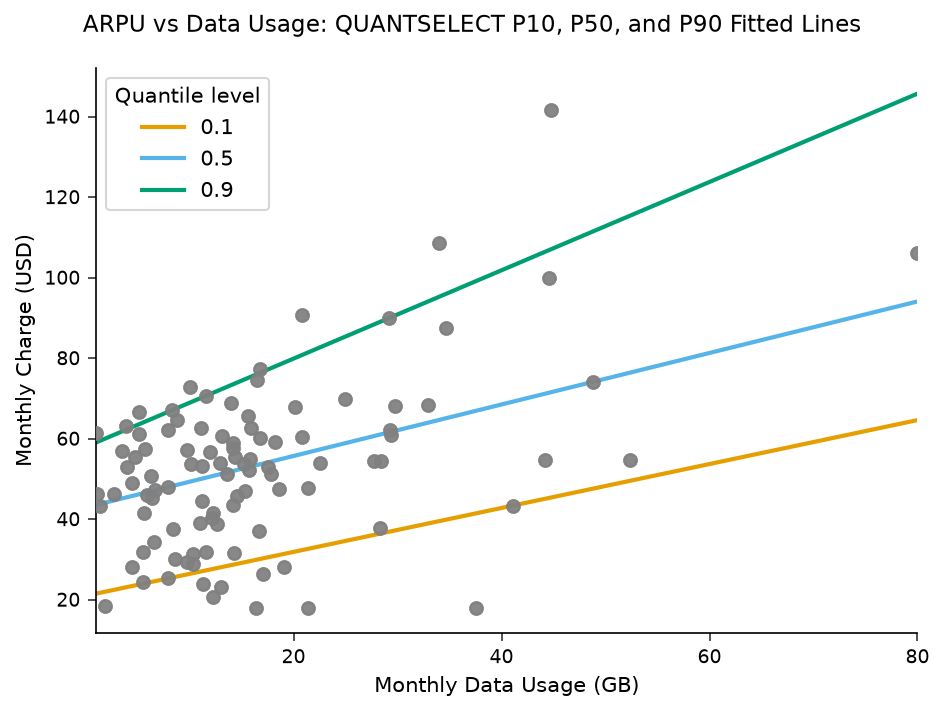

In [5]:
title;  /* clear the carried-over TITLE from the prior step */

proc quantselect data=subscribers;
    model monthly_charge = data_gb / quantile=0.10 0.50 0.90 selection=none;
    output out=qfit p=p_charge ql=qlevel;
run;

proc sort data=qfit; by qlevel data_gb; run;

ods graphics on;
proc sgplot data=qfit;
    title 'ARPU vs Data Usage: QUANTSELECT P10, P50, and P90 Fitted Lines';
    scatter x=data_gb y=monthly_charge
        / markerattrs=(symbol=circlefilled color=gray) transparency=0.4;
    series x=data_gb y=p_charge
        / group=qlevel lineattrs=(thickness=2);
    xaxis label='Monthly Data Usage (GB)';
    yaxis label='Monthly Charge (USD)';
    keylegend / title='Quantile level';
run;
ods graphics off;

## Interpreting the results

**Selection ordered the drivers.** The LASSO path admitted effects in a clear priority order — `contract` first, then `tenure_months`, `streaming_services`, `intl_minutes`, `data_gb`, `region`, and `support_calls` last. AIC fell monotonically from 228.77 (intercept only) to 124.37, and the AIC stopping rule retained all seven effects, confirming every candidate carries signal in this design. The big single-step AIC drop on `contract` (down to 175.82) marks it as the dominant level driver of ARPU.

**Different slopes at different revenue levels.** In the selected model the `data_gb` coefficient climbs across the quantiles — **0.288 USD/GB at P10**, **0.872 at P50**, and **1.057 at P90**. Because we baked heteroscedastic, contract-dependent noise into the data, the data-usage slope is far larger at the top of the distribution than at the bottom: high-ARPU customers are the heavy data users whose bills respond most strongly to each additional gigabyte, while the low end is compressed near the price floor.

**The fan is visible and measurable.** The Step 4 plot shows the three fitted lines diverging as usage rises — the textbook revenue fan. In the single-driver fit the P90 slope (about 1.10 USD/GB) is roughly **2x** the P10 slope (about 0.55), so the conditional gap between a high-spend and a low-spend subscriber widens from about **38 USD** at 1 GB to about **81 USD** near the 80 GB tail.

**Contract and region shifts.** The CLASS terms capture level shifts. Against the Two-Year baseline, month-to-month subscribers sit about **15 USD** below at the low quantile (P10) but only about **2 USD** below at P90 — their disadvantage shrinks among heavy spenders. The Metro region carries a positive ARPU premium that is largest at the low end (about **+8.6 USD** at P10) and fades toward the top. These are level effects: they move where a customer sits in the distribution rather than how steeply their bill responds to usage.

**Business takeaway.** By combining selection with quantile regression, QUANTSELECT lets the carrier (1) prune to the drivers that actually matter and (2) separate *acquisition* levers (what lifts the floor for low-ARPU subscribers) from *expansion* levers (what stretches the ceiling for premium subscribers) — a distinction an OLS mean model would average away entirely. Because the data-usage slope is steepest at P90, data-upsell campaigns return the most among already-high spenders; retention and floor-pricing decisions should lean on the flatter low-quantile relationships and on contract mix, the effect LASSO ranked first.